In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

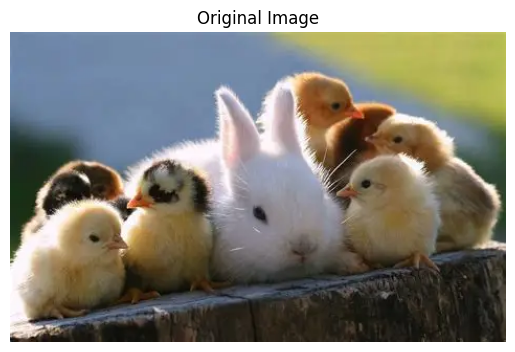

In [40]:
image = cv2.imread("/content/OIP (1).webp")   # Change path if needed

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

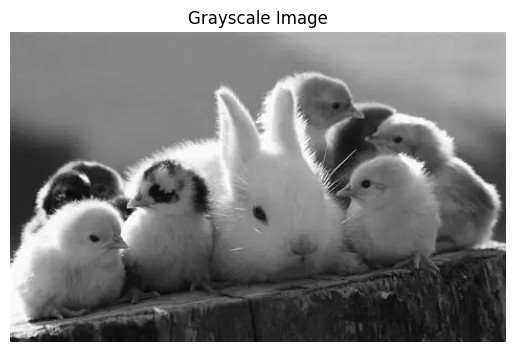

[[131 131 131 ... 185 187 188]
 [131 131 131 ... 183 185 186]
 [131 131 131 ... 178 180 181]
 ...
 [ 16  13  15 ...  37  38  45]
 [ 45  28  26 ...  37  69  85]
 [ 72  34  20 ...  34  57  76]]
Shape: (296, 474)


In [41]:
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

print(gray_image)
print("Shape:", gray_image.shape)

In [42]:
kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

stride = 2

In [43]:
h, w = gray_image.shape

f = kernel.shape[0]

output_height = (h - f) // stride + 1
output_width = (w - f) // stride + 1

output = np.zeros((output_height, output_width))

print("Output Shape:", output.shape)

Output Shape: (147, 236)


In [44]:
out_row = 0

for row in range(0, h - f + 1, stride):

    out_col = 0

    for col in range(0, w - f + 1, stride):

        region = gray_image[row:row+f, col:col+f]

        output[out_row, out_col] = np.sum(region * kernel)

        out_col += 1

    out_row += 1

print(output)

[[131.         131.         131.         ... 180.         180.33333333
  182.33333333]
 [131.33333333 131.33333333 131.33333333 ... 174.66666667 175.
  177.        ]
 [132.         132.         132.         ... 174.66666667 175.
  177.        ]
 ...
 [147.11111111 157.22222222 201.33333333 ...  24.22222222  35.22222222
   51.22222222]
 [ 90.55555556  80.66666667 122.         ...  23.55555556  32.77777778
   50.22222222]
 [ 26.88888889  26.88888889  33.11111111 ...  23.22222222  25.66666667
   41.22222222]]


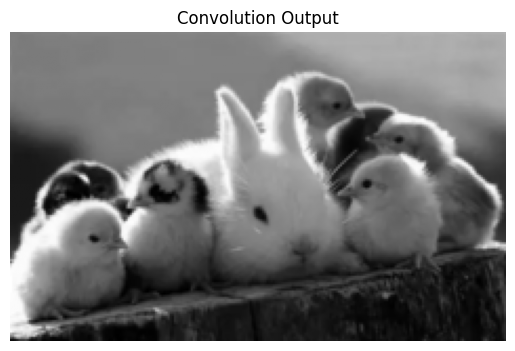

(147, 236)


In [45]:
plt.imshow(output, cmap='gray')
plt.title("Convolution Output")
plt.axis("off")
plt.show()

print(output.shape)

In [46]:
output = np.maximum(0, output)

print(output)

[[131.         131.         131.         ... 180.         180.33333333
  182.33333333]
 [131.33333333 131.33333333 131.33333333 ... 174.66666667 175.
  177.        ]
 [132.         132.         132.         ... 174.66666667 175.
  177.        ]
 ...
 [147.11111111 157.22222222 201.33333333 ...  24.22222222  35.22222222
   51.22222222]
 [ 90.55555556  80.66666667 122.         ...  23.55555556  32.77777778
   50.22222222]
 [ 26.88888889  26.88888889  33.11111111 ...  23.22222222  25.66666667
   41.22222222]]


In [55]:
pool_size = 2
pool_stride = 2

h_out, w_out = output.shape

pooled_height = (h_out - pool_size) // pool_stride + 1
pooled_width = (w_out - pool_size) // pool_stride + 1

pooled_output = np.zeros((pooled_height, pooled_width))

In [56]:
for i in range(pooled_height):

    for j in range(pooled_width):

        row = i * pool_stride
        col = j * pool_stride

        region = output[row:row+pool_size, col:col+pool_size]

        pooled_output[i, j] = np.max(region)

print(pooled_output)

[[131.33333333 131.33333333 132.77777778 ... 180.         180.
  182.33333333]
 [132.         132.         129.22222222 ... 174.66666667 174.66666667
  177.        ]
 [132.         132.         130.11111111 ... 172.66666667 173.55555556
  176.44444444]
 ...
 [245.55555556 240.44444444 242.44444444 ...  36.22222222  27.77777778
   53.55555556]
 [247.55555556 224.55555556 224.55555556 ...  31.11111111  28.33333333
   51.55555556]
 [157.22222222 217.22222222 212.44444444 ...  35.55555556  28.22222222
   51.22222222]]


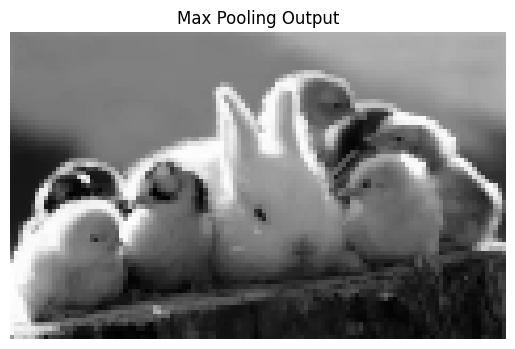

(73, 118)


In [57]:
plt.imshow(pooled_output, cmap='gray')
plt.title("Max Pooling Output")
plt.axis("off")
plt.show()

print(pooled_output.shape)

In [58]:
flattened_output = pooled_output.flatten()

print("Shape of flattened_output:", flattened_output.shape)

print(flattened_output)

Shape of flattened_output: (8614,)
[131.33333333 131.33333333 132.77777778 ...  35.55555556  28.22222222
  51.22222222]


In [59]:
output_size = flattened_output.shape[0]

weights = np.random.rand(output_size)

print("Shape of weights:", weights.shape)

print("First 10 weights:")

print(weights[:10])

Shape of weights: (8614,)
First 10 weights:
[0.22667919 0.20162301 0.82576343 0.11265698 0.86133976 0.06819919
 0.96564237 0.41019743 0.06601508 0.09139845]


In [60]:
bias = np.random.rand()

print("Bias:", bias)

Bias: 0.3779165510226209


In [61]:
classification_output = np.dot(flattened_output, weights)

print("Classification Output:")

print(classification_output)

Classification Output:
517008.46977355017


In [62]:
final_output = np.dot(flattened_output, weights) + bias

print("Final Classification Output:")

print(final_output)

Final Classification Output:
517008.8476901012


In [63]:
print("Original:", gray_image.shape)
print("After Convolution:", output.shape)
print("After Pooling:", pooled_output.shape)

Original: (296, 474)
After Convolution: (147, 236)
After Pooling: (73, 118)


USING KERAS


In [65]:
import kagglehub

path = kagglehub.dataset_download("cactus3/basicshapes")

print("Dataset Path:", path)

100%|██████████| 402k/402k [00:00<00:00, 61.9MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/cactus3/basicshapes/versions/1


In [66]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [67]:
data = []
labels = []

categories = [
    "/shapes/circles",
    "/shapes/squares"
]

for category in categories:

    folder_path = path + category

    label = 0 if category == "/shapes/circles" else 1

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (64, 64))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        data.append(img)

        labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Total Images:", len(data))
print("Circles:", np.sum(labels == 0))
print("Squares:", np.sum(labels == 1))

Total Images: 200
Circles: 100
Squares: 100


In [68]:
data = data / 255.0

data = data.reshape(-1, 64, 64, 1)

print("Data Shape:", data.shape)

Data Shape: (200, 64, 64, 1)


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 160
Testing Samples: 40


In [70]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,1)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(
    optimizer=Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [73]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.4938 - loss: 0.7082 - val_accuracy: 0.5250 - val_loss: 0.6925
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5063 - loss: 0.6983 - val_accuracy: 0.4750 - val_loss: 0.6954
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.5063 - loss: 0.6929 - val_accuracy: 0.5250 - val_loss: 0.6918
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - accuracy: 0.4938 - loss: 0.6931 - val_accuracy: 0.5250 - val_loss: 0.6919
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.4938 - loss: 0.6916 - val_accuracy: 0.6500 - val_loss: 0.6906
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.5813 - loss: 0.6891 - val_accuracy: 0.5250 - val_loss: 0.6846
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.5562 - loss: 0.6771 - val_accuracy: 0.5250 - val_loss: 0.6748
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.5813 - loss: 0.6564 - val_accuracy: 0.

In [74]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8500 - loss: 0.2709
Test Loss: 0.2709365785121918
Test Accuracy: 0.8500000238418579


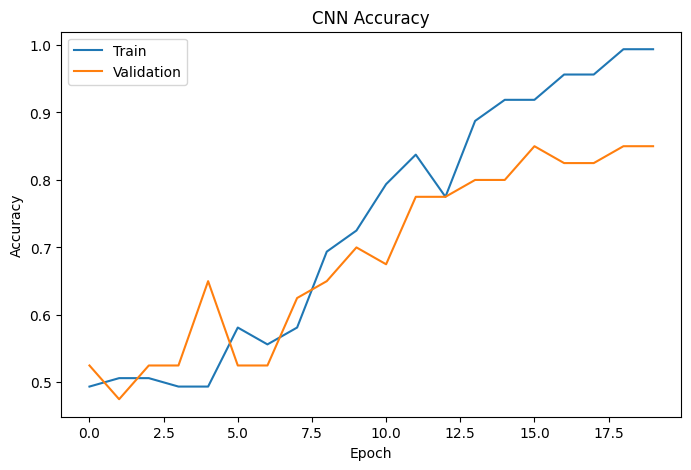

In [75]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()